In [ ]:
# import packages
from tifffile import TiffFile
from tifffile import imread, imwrite
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
import math
import os
from scipy import ndimage
from tifffile import tiffcomment
import xmltodict
import scanpy as sc

from cupyx.scipy.signal import fftconvolve
sc.set_figure_params(dpi=80)

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [ ]:
import matplotlib.patches as patches
from scipy import sparse
from shapely import Polygon, Point, affinity, intersection, MultiPolygon, MultiPoint
from geopandas.geodataframe import GeoDataFrame
import geopandas as gpd
import scanpy as sc


In [ ]:
plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def write_object(myObject, file):
    import dill
    with open(file, 'wb') as f:
        f.write(dill.dumps(myObject))

def read_object(file):
    import dill
    with open(file, 'rb') as f:
        myObject = dill.loads(f.read())
    return myObject

def flatten(my_list):
    return(list(itertools.chain(*my_list)))
    
def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

In [ ]:
from skimage.filters import threshold_otsu

# Modified from skimage package
def threshold_triangle(hist, upper = True):
    bin_centers = hist[1]
    hist = hist[0].copy()
    nbins = len(hist)

    # Find peak, lowest and highest gray levels.
    arg_peak_height = np.argmax(hist)
    peak_height = hist[arg_peak_height]
    arg_low_level, arg_high_level = np.flatnonzero(hist)[[0, -1]]

    if(upper):
        flip=True
    else:
        flip=False
    # Flip is True if left tail is shorter.
    #flip = arg_peak_height - arg_low_level < arg_high_level - arg_peak_height
    if flip:
        hist = hist[::-1]
        arg_low_level = nbins - arg_high_level - 1
        arg_peak_height = nbins - arg_peak_height - 1

    # If flip == True, arg_high_level becomes incorrect
    # but we don't need it anymore.
    del(arg_high_level)

    # Set up the coordinate system.
    width = arg_peak_height - arg_low_level
    x1 = np.arange(width)
    y1 = hist[x1 + arg_low_level]

    # Normalize.
    norm = np.sqrt(peak_height**2 + width**2)
    peak_height /= norm
    width /= norm

    # Maximize the length.
    # The ImageJ implementation includes an additional constant when calculating
    # the length, but here we omit it as it does not affect the location of the
    # minimum.
    length = peak_height * x1 - width * y1
    arg_level = np.argmax(length) + arg_low_level

    if flip:
        arg_level = nbins - arg_level - 1

    return bin_centers[arg_level]

In [ ]:
def imnormalize(img, quantile_low = 0.1, quantile_high = 0.99):
    img = img - np.quantile(np.ravel(img), quantile_low)
    img = img / np.quantile(np.ravel(img), quantile_high)
    img = np.clip(img, 0, 1)
    return(img)

def im2rgb(IM, color, quantile_high = 0.99, quantile_low = 0.1):
    norm = imnormalize(IM, quantile_low = quantile_low, quantile_high = quantile_high)
    RGB = np.zeros(list(norm.shape) + [3])
    for i in range(len(color)):
        RGB[...,i] = color[i] * norm
    return(RGB)

def imblend(G, R = [], B = []):
    G = im2rgb(G, [0,1,0])
    if len(R) > 0:
        R = im2rgb(R, [1,0,0])
    else:
        R = np.zeros(R.shape)
    if len(B) > 0:
        B = im2rgb(B, [0,0,1])
    else:
        B = np.zeros(B.shape)
    IM = R + G + B
    return(IM)

def imoverlay(IM, mask, color=[1,1,1], px=0):
    from skimage.segmentation import find_boundaries
    if len(IM.shape) == 2:
        overlay_data = im2rgb(IM, [1,1,1])
    else:
        overlay_data = IM.copy()
    boundary = find_boundaries(mask, connectivity=1, mode='inner')
    boundary_mask = np.zeros(overlay_data.shape[:2])
    boundary_mask[boundary > 0] = 1
    if px > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(px,px))
        boundary_mask = cv2.dilate(boundary_mask,kernel,iterations = 1)
    for i in range(len(color)):
        overlay_data[boundary_mask > 0,i] = color[i]
    return(overlay_data)


In [ ]:
def get_thresholds(vals, bins=500):
    h, bins = np.histogram(vals, bins = bins)
    my_threshold_triangle = threshold_triangle([h, bins])
    bin_2 = bins[:-1] + np.diff(bins)[0]
    my_threshold_otsu = threshold_otsu(hist = [h, bin_2])
    
    plt.figure(figsize = [3,2])
    plt.stairs(h, bins)
    plt.plot([my_threshold_triangle]*2, plt.gca().get_ylim(), 'r--')
    plt.plot([my_threshold_otsu]*2, plt.gca().get_ylim(), 'k--')
    plt.xlabel("log10 intensity")
    plt.ylabel("Density")

    return(my_threshold_triangle, my_threshold_otsu)

Identify TNC file

In [ ]:
rawdatapath = '../raw_data/'
possible_files = np.sort(os.listdir(rawdatapath))
TNC_file = grep("TNC", possible_files)[0]
TNC_file

np.str_('SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif')

In [ ]:
manual_mask_path = '../manual_masks/'
possible_files = np.sort(os.listdir(manual_mask_path))
TNC_mask_file = grep("manual_mask", grep("TNC", possible_files))[0]
TNC_mask_file

np.str_('SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F__manual_mask.ome.tif')

Read file and mask

In [ ]:
TNC_mask = imread(os.path.join(manual_mask_path, TNC_mask_file))
TNC_IM = imread(os.path.join(rawdatapath, TNC_file))

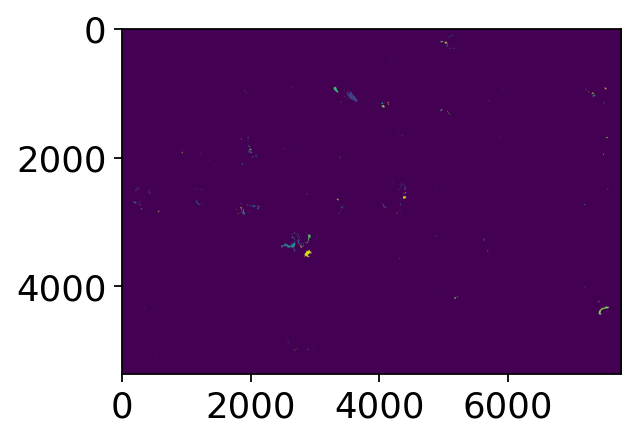

In [ ]:
TNC_mask_thumb = cv2.resize(TNC_mask, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_LINEAR)
plt.imshow(TNC_mask_thumb)

Extract pixels from manual mask

In [ ]:
valid_pixels = TNC_IM[TNC_mask > 0]

Identify threshold to binarize TNC

In [ ]:
h, bins = np.histogram(np.log1p(valid_pixels)/np.log(10), bins = 100, density = True)
tnc_threshold_triangle = threshold_triangle([h, bins])
bin_2 = bins[:-1] + np.diff(bins)[0]
tnc_threshold_otsu = threshold_otsu(hist = [h, bin_2])

Text(0, 0.5, 'Density')

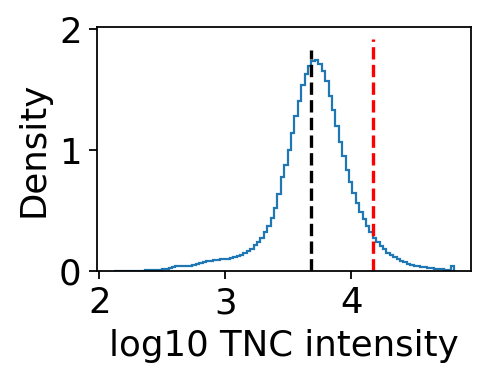

In [ ]:
plt.figure(figsize = [3,2])
plt.stairs(h, bins)
plt.plot([tnc_threshold_otsu]*2, plt.gca().get_ylim(), 'k--')
plt.plot([tnc_threshold_triangle]*2, plt.gca().get_ylim(), 'r--')
plt.xlabel("log10 TNC intensity")
plt.ylabel("Density")

Binarize image and clean up noise

In [ ]:
TNC_IM_thresholded = np.multiply((TNC_IM > np.power(10, tnc_threshold_triangle)), (TNC_mask > 0).astype(np.uint8)).astype(np.uint8)
TNC_IM_thresholded_thumb = cv2.resize(TNC_IM_thresholded, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_LINEAR)
TNC_IM_thumb = cv2.resize(TNC_IM, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_LINEAR)


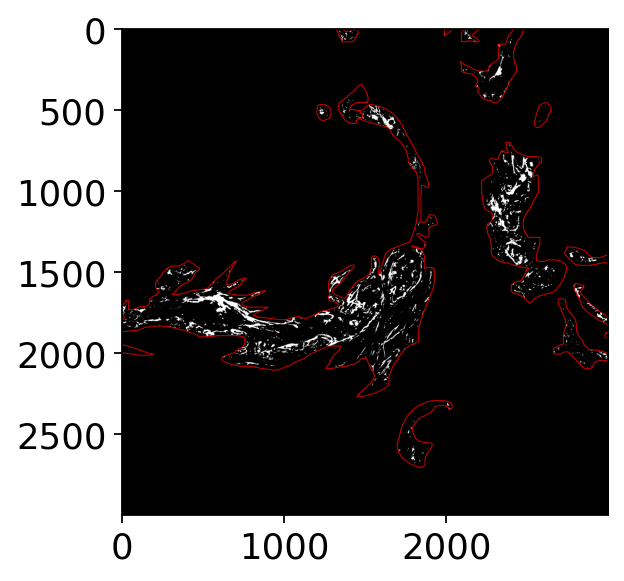

In [ ]:
representative_image = TNC_IM_thresholded[32000:35000,25000:28000]
representative_mask = TNC_mask[32000:35000,25000:28000]
plt.imshow(imoverlay(representative_image, representative_mask, [1,0,0], px = 5))

Identify valid pixels

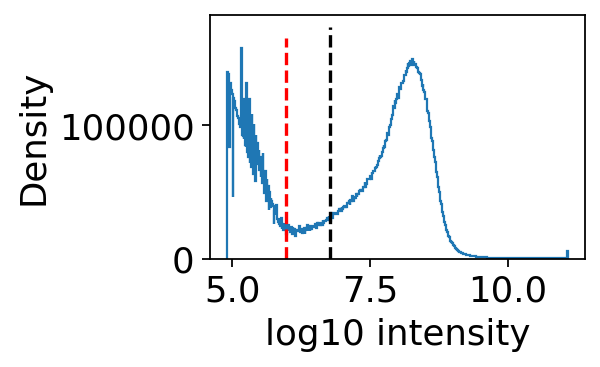

In [ ]:
TNC_values = np.ravel(np.log1p(TNC_IM_thumb))
TNC_values = TNC_values[TNC_values > 4.9]
TNC_threshold_triangle, TNC_threshold_otsu = get_thresholds(TNC_values)

In [ ]:
TNC_binary = (TNC_IM_thumb > np.exp(TNC_threshold_triangle)).astype(np.uint8)

disk_radius = 1 
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * disk_radius + 1, 2 * disk_radius + 1)) 
TNC_binary = cv2.dilate(TNC_binary, kernel, iterations=1) 

TNC_binary = cv2.morphologyEx(TNC_binary, cv2.MORPH_OPEN, kernel)
TNC_binary = cv2.erode(TNC_binary, kernel, iterations=1) 
TNC_binary = cv2.morphologyEx(TNC_binary, cv2.MORPH_CLOSE, kernel)

TNC_filled_image = ndimage.binary_fill_holes(TNC_binary).astype(np.uint8)

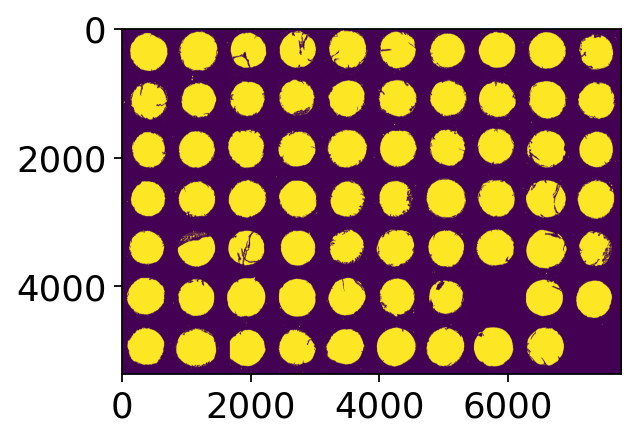

In [ ]:
plt.imshow(TNC_filled_image)

In [ ]:
TNC_mask = cv2.resize(TNC_filled_image, TNC_IM.shape[::-1], interpolation=cv2.INTER_LINEAR)
tnc_sub = TNC_IM[30000:40000, 30000:40000]
tnc_mask_sub = TNC_mask[30000:40000, 30000:40000]


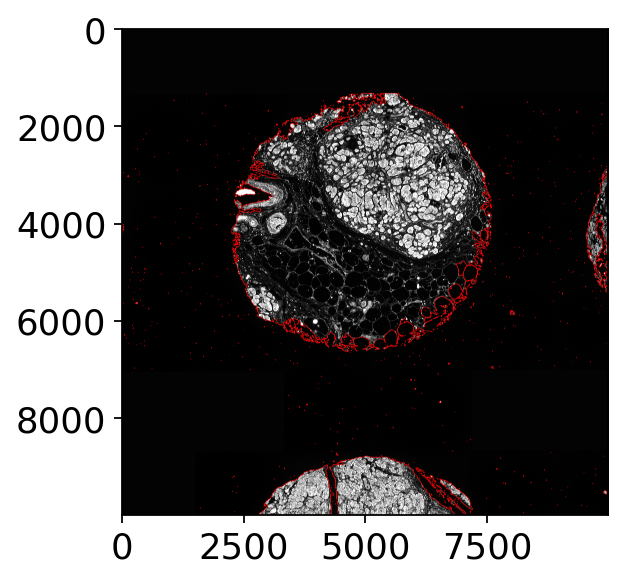

In [ ]:
plt.imshow(imoverlay(im2rgb(tnc_sub, [1,1,1]), tnc_mask_sub, [1,0,0], px = 10))

### Write binary images

In [ ]:
tnc_mask_file = "../binarized/TNC_positive_regions.tif"
#imwrite(tnc_mask_file, TNC_IM_thresholded)

In [ ]:
tnc_mask_file = "../binarized/patient_core_binarized.tif"
#imwrite(tnc_mask_file, TNC_mask)

### Alternative: manual approach

Load manual binarized mask, and intersect with manual binarized regions

In [ ]:
tnc_mask_file = "../binarized/TNC_positive_regions.tif"
TNC_mask = imread(tnc_mask_file)

tnc_mask_pixels = "../binarized/tnc_classifier.ome.tif"
TNC_pixels = imread(tnc_mask_pixels)

rawdatapath = '../raw_data/'
possible_files = np.sort(os.listdir(rawdatapath))
TNC_file = grep("TNC", possible_files)[0]
TNC_IM = imread(os.path.join(rawdatapath, TNC_file))

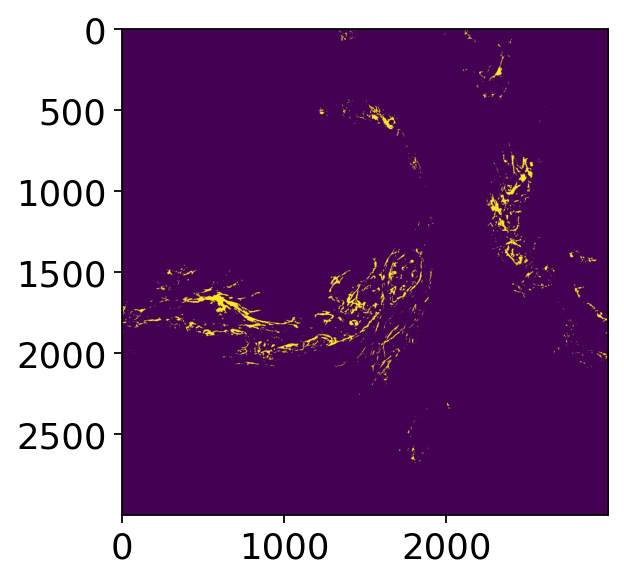

In [ ]:
TNC_mask_intersect = np.multiply(TNC_mask, TNC_pixels)
plt.imshow(TNC_mask_intersect[32000:35000,25000:28000])

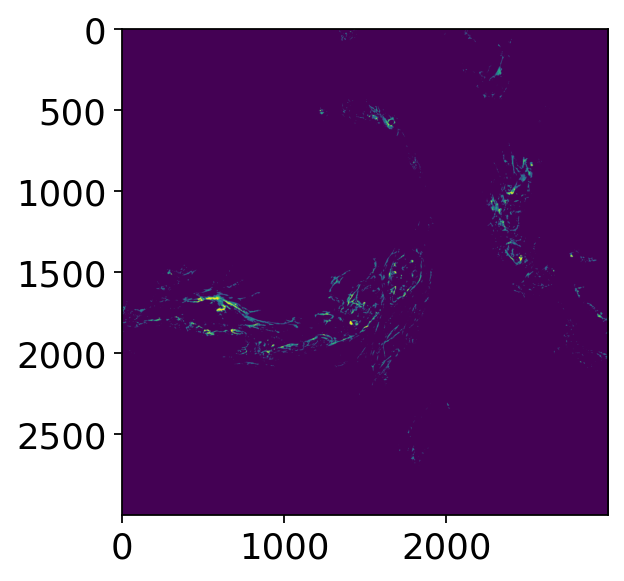

In [ ]:
TNC_intensity_masked = np.multiply(TNC_IM, TNC_mask_intersect)
plt.imshow(TNC_intensity_masked[32000:35000,25000:28000])

## Quantify data and save to data frame

In [ ]:
adata = sc.read_h5ad("../preprocessed/05_adata.h5ad")

In [ ]:
def get_circles(centers_x, centers_y, outer_radius):
    df = pd.DataFrame({'centers_x': centers_x, 'centers_y': centers_y})
    gdf_points = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.centers_x, df.centers_y))
    gdf_circles = gdf_points.copy()
    gdf_circles['geometry'] = gdf_points.geometry.buffer(outer_radius)
    return(gdf_circles)

gdf_circles = get_circles(adata.obsm['X_spatial_px'][:,0], adata.obsm['X_spatial_px'][:,1], 30)
gdf_circles.index = adata.obs_names

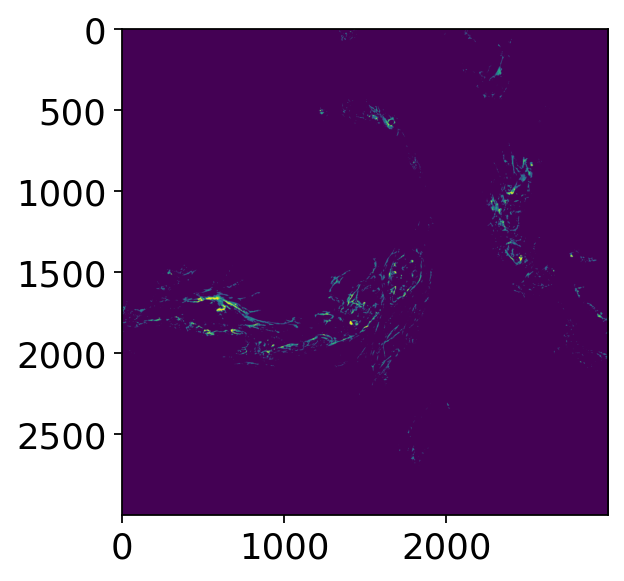

In [ ]:
TNC_intensity_masked = np.multiply(TNC_IM, TNC_mask_intersect)
plt.imshow(TNC_intensity_masked[32000:35000,25000:28000])

In [ ]:
filename = '../raw_data/SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif'
ome_xml = tiffcomment(filename)
my_dict = xmltodict.parse(ome_xml)
pixel_size = float(my_dict['OME']['Image']['Pixels']['@PhysicalSizeX'])

In [ ]:
y_coords, x_coords = np.where(TNC_intensity_masked > 0)
masked_intensities = TNC_intensity_masked[y_coords, x_coords]

y_coords_px = -y_coords * pixel_size
x_coords_px = x_coords * pixel_size

gdf_points = gpd.GeoDataFrame(geometry = [Point(x,y) for x,y in zip(x_coords_px, y_coords_px)])
gdf_points['intensity'] = masked_intensities

In [ ]:
joined = gdf_circles.sjoin(gdf_points)
joined = joined.reset_index()

In [ ]:
tnc_value = np.array([0] * adata.n_obs, dtype = np.uint16)
tnc_count = joined.groupby('index').agg('count')['index_right']
tnc_value[ismember(tnc_count.index.to_numpy(), adata.obs_names)[0]] = tnc_count.to_numpy()
adata.obs['tnc_positive_pixels_manual'] = tnc_value

tnc_count = joined.loc[:,['index', 'intensity']].groupby('index').agg('mean')['intensity']
tnc_value[ismember(tnc_count.index.to_numpy(), adata.obs_names)[0]] = tnc_count.to_numpy()
adata.obs['tnc_positive_pixels_intensity_manual'] = tnc_value


Automated option

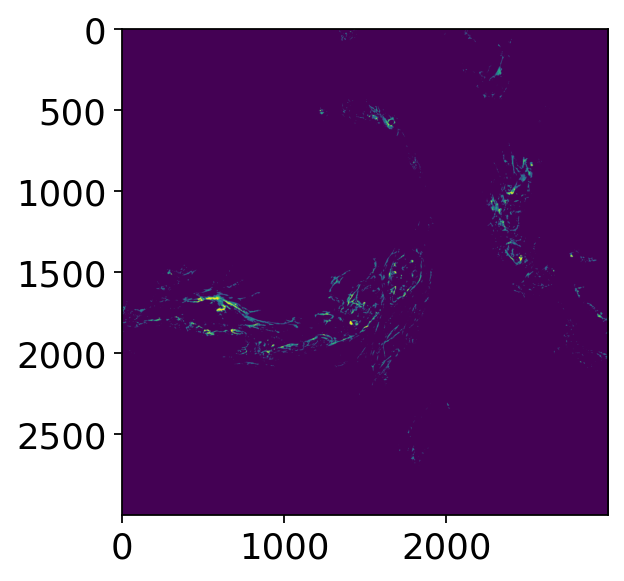

In [ ]:
TNC_intensity_masked = np.multiply(TNC_IM, TNC_IM_thresholded)
plt.imshow(TNC_intensity_masked[32000:35000,25000:28000])

In [ ]:
y_coords, x_coords = np.where(TNC_intensity_masked > 0)
masked_intensities = TNC_intensity_masked[y_coords, x_coords]

y_coords_px = -y_coords * pixel_size
x_coords_px = x_coords * pixel_size

gdf_points = gpd.GeoDataFrame(geometry = [Point(x,y) for x,y in zip(x_coords_px, y_coords_px)])
gdf_points['intensity'] = masked_intensities

joined = gdf_circles.sjoin(gdf_points)
joined = joined.reset_index()

tnc_value = np.array([0] * adata.n_obs, dtype = np.uint16)
tnc_count = joined.groupby('index').agg('count')['index_right']
tnc_value[ismember(tnc_count.index.to_numpy(), adata.obs_names)[0]] = tnc_count.to_numpy()
adata.obs['tnc_positive_pixels_auto'] = tnc_value

tnc_count = joined.loc[:,['index', 'intensity']].groupby('index').agg('mean')['intensity']
tnc_value[ismember(tnc_count.index.to_numpy(), adata.obs_names)[0]] = tnc_count.to_numpy()
adata.obs['tnc_positive_pixels_intensity_auto'] = tnc_value


In [ ]:
selected_obs = [
    'tnc_positive_pixels_auto',
    'tnc_positive_pixels_intensity_auto',
    'tnc_positive_pixels_manual',
    'tnc_positive_pixels_intensity_manual',
]

adata.obs[selected_obs].to_csv("../binarized/06_tnc_quantification.csv.gz")

In [ ]:
adata_sub = adata[adata.obs['core_id'] == 43,:].copy()

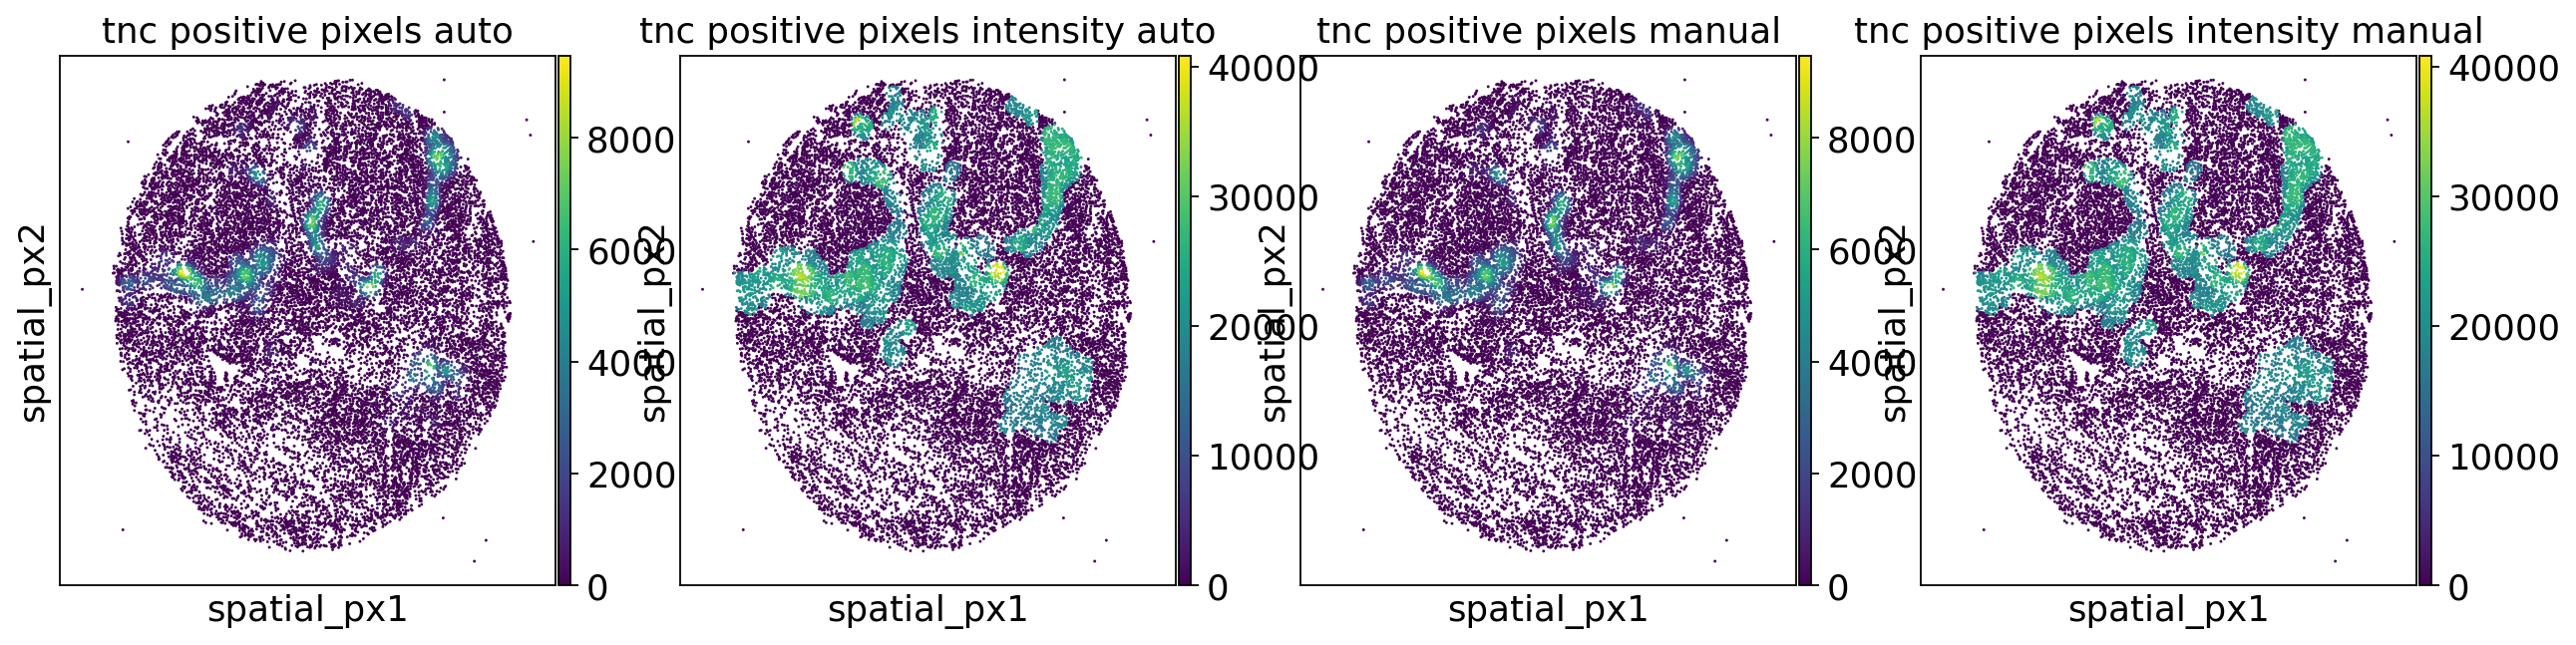

In [ ]:
sc.pl.scatter(adata_sub, color=selected_obs, basis = 'spatial_px')

In [ ]:
sc.write("../preprocessed/06_adata.h5ad", adata = adata)